In [961]:
import pandas as pd
import numpy as np

In [962]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

df = pd.read_csv(url)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [963]:
#Cleanin' dataset

In [964]:
#Cleaning column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [965]:
#Cleaning data
columns = df.columns[df.dtypes == 'str']
for col in columns:
    df[col] = df[col].str.replace(' ', '_').str.lower()
df = df.fillna(0)


In [966]:
#Encoding categorical features
df.nunique().to_list

<bound method IndexOpsMixin.tolist of make                   48
model                 914
year                   28
engine_fuel_type       11
engine_hp             357
engine_cylinders        9
transmission_type       5
driven_wheels           4
number_of_doors         4
market_category        72
vehicle_size            3
vehicle_style          16
highway_mpg            59
city_mpg               69
popularity             48
msrp                 6049
dtype: int64>

In [967]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

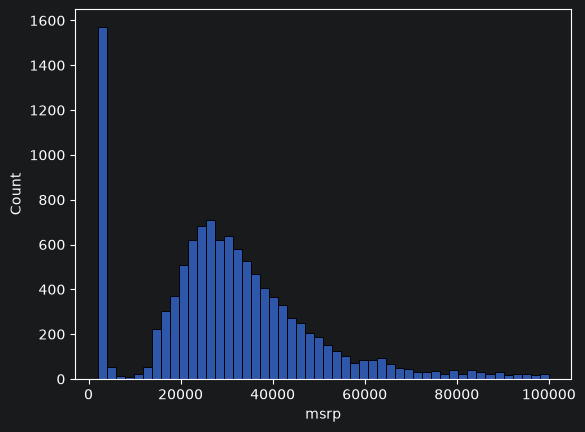

In [968]:
sns.histplot(df.msrp[df.msrp<100000], bins=50) #long tail distribution

<Axes: xlabel='msrp', ylabel='Count'>

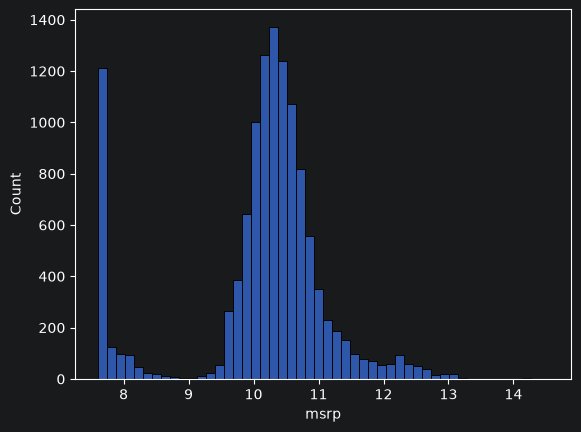

In [969]:
sns.histplot(np.log1p(df.msrp), bins=50)

In [970]:
n = len(df)

validation_n = int(n*0.2)

test_n = int(n*0.2)

train_n = n - validation_n - test_n

print(validation_n, test_n, train_n)

2382 2382 7150


In [971]:
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

In [972]:
df_train = df.iloc[idx[:train_n]]
df_val = df.iloc[idx[train_n:train_n+validation_n]]
df_test = df.iloc[idx[train_n+validation_n:]]

In [973]:
df_train = df_train.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)

In [974]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [975]:
#removing target from the features
del df_train['msrp']
del df_test['msrp']
del df_val['msrp']

In [976]:
def linear_regression(xi, wi):
    n = len(xi)
    pred = wi[0]
    for j in range(n):
        pred += xi[j]*wi[j]
    return pred

In [977]:
#X Baseline -- only numerical
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [978]:
categorical_features= df_train.columns.difference(base+['year']+['number_of_doors'])
cf_values = {}
#creating dictionary of categorical features and their top values
for cf in categorical_features:
    top_k_number = max(min(len(df_train[cf].value_counts())-1, 5),1) #avoiding dummy variable trap
    cf_values[cf] = df_train[cf].fillna(0).value_counts().head(top_k_number).index

In [979]:
def prepare_X(df):
    df = df.copy()

    #feature engineering
    df['age'] = 2017 - df['year']

    features = base + ['age']

    #categorical 'number of doors' to boolean columns

    types_by_doors = [0, 3, 4]
    for type in types_by_doors:
        df['num_doors_%s' % type ] = (df['number_of_doors'] == type).astype(int)
        features.append('num_doors_%s' % type)
    for cf in categorical_features:
        for val in cf_values[cf]:
            df[f'{cf}_{val}'] = (df[cf] == val).astype(int)
            features.append(f'{cf}_{val}')
    X = df[features].fillna(0).values
    X = np.column_stack([np.ones(X.shape[0]), X]) #fictional column of ones for w_0
    return X

In [1015]:
def train_linear_regression(X, y, r = 0.1):
    XTX = X.T@X
    XTX = XTX + r * np.eye(XTX.shape[0]) #regularization here is redundant -- it only underfits the model
    w = np.linalg.inv(XTX) @ X.T @ y
    return w

In [981]:
def predict(X, w):
    predictions = X @ w
    return predictions

In [982]:
def RMSE(y, y_pred):
    n = len(y)
    rmse = np.sqrt(np.mean((y-y_pred)**2))
    return rmse

44
44
0.4470766080154344
0 0.45096929975464417 10.137199193249751
0.1 0.45105897678077733 10.065636018876244
1 0.4524378225794852 9.521870213130125
10 0.4801308874069311 7.129314621727088
100 0.6316321918759442 3.9059546754000523
1000 0.9325594640581277 1.5506110619459923
10000 1.2498738163069023 0.4693877162935628


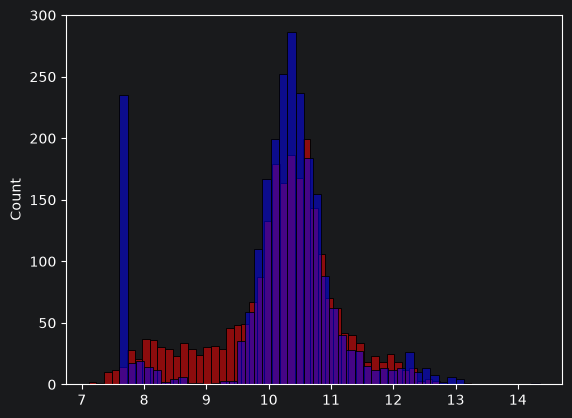

In [1018]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)
X_test = prepare_X(df_test)

print(np.linalg.matrix_rank(X_train))
print(X_train.shape[1])

w = train_linear_regression(X_train, y_train, 0)
y_pred = predict(X_test, w)
rmse = RMSE(y_test, y_pred)

print(rmse)

sns.histplot(y_pred, color = 'red', alpha = 0.5, bins = 50)
sns.histplot(y_test, color = 'blue', alpha = 0.5, bins = 50)

#finding the bes r param. The best one is r = 0
for r in [0, 0.1, 1, 10, 100, 1000, 10000]:
    w = train_linear_regression(X_train, y_train, r)
    y_pred = predict(X_val, w)
    print(r, RMSE(y_val, y_pred), np.linalg.norm(w))


In [1022]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True)
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

w = train_linear_regression(X_full_train, y_full_train, 0)
y_pred = predict(X_test, w)
rmse = RMSE(y_test, y_pred)

np.float64(0.44645855639184817)